<a href="https://colab.research.google.com/github/scxbbard/Data-science-classes/blob/main/(poisson)Zoey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
df = pd.read_csv("/content/day.csv")

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Rows and columns

In [51]:
rows, columns = df.shape
output =f'The data has {rows} rows and {columns} columns'
print(output)

The data has 731 rows and 16 columns


Info

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


No null values

In [53]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Columns

In [54]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [55]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [56]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [57]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [58]:
df['cnt']

,cnt
0,985
1,801
2,1349
3,1562
4,1600
...,...
726,2114
727,3095
728,1341
729,1796


In [59]:
mean = df['cnt'].mean()
variance = df['cnt'].var()
print(f"Mean: {mean} | Variance: {variance}")
print(f"Are they equal or not? {mean == variance}")

Mean: 4504.3488372093025 | Variance: 3752788.2082828935
Are they equal or not? False


In [60]:
lambda_esti = np.mean(df['cnt'])


In [65]:

k = 4000

##(PMF) k = 100
p_exact = stats.poisson.pmf(k, lambda_esti)

#(CDF) k<=100:
p_atmost = stats.poisson.cdf(k, lambda_esti)

#1 - (CDF)k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_esti)

print(f"Probability of exactly {k} rentals: {p_exact}")
print(f"Probability of at most {k} rentals: {p_atmost}")
print(f"Probability of at least {k} rentals: {p_atleast}")


Probability of exactly 4000 rentals: 1.1273435361475248e-15
Probability of at most 4000 rentals: 9.917477880531588e-15
Probability of at least 4000 rentals: 0.9999999999999901


In [66]:

k = 3000

##(PMF) k = 100
p_exact = stats.poisson.pmf(k, lambda_esti)

#(CDF) k<=100:
p_atmost = stats.poisson.cdf(k, lambda_esti)

#1 - (CDF)k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_esti)

print(f"Probability of exactly {k} rentals: {p_exact}")
print(f"Probability of at most {k} rentals: {p_atmost}")
print(f"Probability of at least {k} rentals: {p_atleast}")


Probability of exactly 3000 rentals: 1.1593778538405672e-126
Probability of at most 3000 rentals: 3.466852757030557e-126
Probability of at least 3000 rentals: 1.0


In [86]:

k = 2900

##(PMF) k = 100
p_exact = stats.poisson.pmf(k, lambda_esti)

#(CDF) k<=100:
p_atmost = stats.poisson.cdf(k, lambda_esti)

#1 - (CDF)k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_esti)

print(f"Probability of exactly {k} rentals: {p_exact}")
print(f"Probability of at most {k} rentals: {p_atmost}")
print(f"Probability of at least {k} rentals: {p_atleast}")


Probability of exactly 2900 rentals: 4.880975035089603e-145
Probability of at most 2900 rentals: 1.3688392892628772e-144
Probability of at least 2900 rentals: 1.0


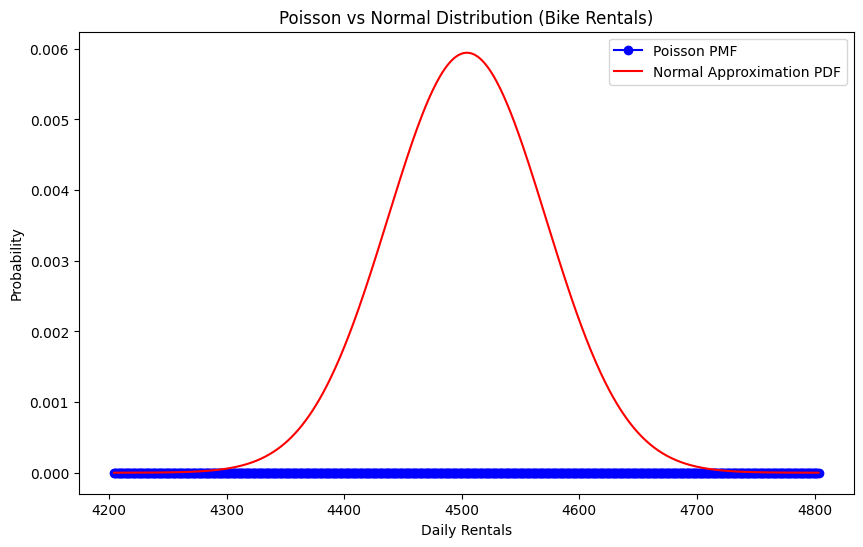

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

# Estimate lambda from your dataset
lambda_est = df['cnt'].mean()

# Range around the mean
x = np.arange(lambda_est - 300, lambda_est + 300)

# Poisson PMF
poisson_pmf = poisson.pmf(x, lambda_est)

# Normal approximation (mean = λ, variance = λ)
normal_pdf = norm.pdf(x, loc=lambda_est, scale=np.sqrt(lambda_est))

# Plot both
plt.figure(figsize=(10,6))
plt.plot(x, poisson_pmf, 'bo-', label='Poisson PMF')
plt.plot(x, normal_pdf, 'r-', label='Normal Approximation PDF')
plt.title("Poisson vs Normal Distribution (Bike Rentals)")
plt.xlabel("Daily Rentals")
plt.ylabel("Probability")
plt.legend()
plt.show()
